# 8. Benchmarking and Statistical Comparison

Chapter 7 produced a ranking of seven algorithms on one dataset and declared logistic regression the winner. This chapter asks two questions that ranking cannot answer.

First: **was that gap real, or noise?** Chapter 2 measured fold-to-fold spread large enough to swallow most of the differences in that table.

Second: **does it generalise?** A winner on 768 rows of one medical dataset is a fact about that dataset.

**You will learn:**

- how to run many models across many datasets in one call
- when a difference between two scores is statistically meaningful
- why average ranks across datasets beat average scores
- how to read a critical difference diagram
- how to export results for a paper or a report

**Prerequisites:** chapters 2 and 7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

from tuiml import Benchmark

[tuiml] loaded 2 user algorithm(s)


## 8.1 One dataset is one data point

The temptation after chapter 7 is to conclude "logistic regression is the better algorithm". It is not what we measured. We measured that logistic regression scored higher on the Pima diabetes data, once, with one preprocessing choice and one set of folds.

To say anything more general you need more datasets. `Benchmark` runs a full cross-product: every model on every dataset, identical folds, identical preprocessing.

In [2]:
benchmark = Benchmark(
    models=[
        {"name": "LogisticRegression"},
        {"name": "RandomForestClassifier", "params": {"n_estimators": 100}},
        {"name": "NaiveBayesClassifier"},
        {"name": "ZeroRuleClassifier"},
    ],
    datasets=[
        {"source": name}
        for name in ["diabetes", "iris", "glass", "ionosphere",
                     "vote", "breast-cancer", "credit-g", "soybean"]
    ],
    pipeline=[{"name": "SimpleImputer", "params": {"strategy": "most_frequent"}}],
    evaluation={"cv": 10},
    random_seed=42,
    task="classification",
)

benchmark.run()
print("4 models x 8 datasets x 10 folds = 320 model fits")

4 models x 8 datasets x 10 folds = 320 model fits


> **Remark — the imputation step is not optional here.** Several of these datasets contain missing values, and the four models disagree about what to do with them. `RandomForestClassifier` handles `NaN` natively: on `vote`, 10-fold CV gives 0.961 ± 0.025 without imputation and 0.966 ± 0.027 with it. `NaiveBayesClassifier` copes too. `LogisticRegression` does not — and it does not complain either. It accepts the `NaN` and scores **0.614 ± 0.004** where imputing first gives **0.963 ± 0.023**. That silence is the real hazard: a crash would at least tell you something was wrong, whereas here you would read the table, conclude logistic regression is a poor fit for this dataset, and move on. Putting a `SimpleImputer` in the benchmark's `pipeline` puts every model on the same footing — and, per chapter 4, it is fitted inside each fold rather than up front.

In [3]:
benchmark.table()

model,LogisticRegression,RandomForestClassifier,NaiveBayesClassifier,ZeroRuleClassifier
dataset,,,,
diabetes,0.7798 ± 0.0451,0.7682 ± 0.0494,0.7525 ± 0.0534,0.6511 ± 0.0036
iris,0.9600 ± 0.0562,0.9533 ± 0.0549,0.9533 ± 0.0549,0.3333 ± 0.0000
glass,0.6411 ± 0.1161,0.7915 ± 0.1277,0.4221 ± 0.1354,0.3557 ± 0.0151
ionosphere,0.8719 ± 0.0548,0.9348 ± 0.0420,0.8862 ± 0.0640,0.6411 ± 0.0060
vote,0.9633 ± 0.0245,0.9657 ± 0.0288,0.9336 ± 0.0506,0.6138 ± 0.0039
breast-cancer,0.7128 ± 0.0759,0.7206 ± 0.0856,0.7241 ± 0.0880,0.7030 ± 0.0123
credit-g,0.7590 ± 0.0288,0.7660 ± 0.0350,0.7260 ± 0.0327,0.7000 ± 0.0000
soybean,0.9357 ± 0.0257,0.9430 ± 0.0216,0.8768 ± 0.0225,0.1348 ± 0.0050


## 8.2 The winner is dataset-dependent

In [4]:
benchmark.best()

,best_model,best_score
dataset,,
diabetes,LogisticRegression,0.779836
iris,LogisticRegression,0.960000
glass,RandomForestClassifier,0.791460
ionosphere,RandomForestClassifier,0.934813
vote,RandomForestClassifier,0.965693
breast-cancer,NaiveBayesClassifier,0.724089
credit-g,RandomForestClassifier,0.766000
soybean,RandomForestClassifier,0.943009
overall,RandomForestClassifier,1.437500


This is the result that matters, and it complicates chapter 7's conclusion rather than confirming it.

Logistic regression does win on `diabetes` — chapter 7 was right about that. But the random forest wins on five of the eight, and takes the best overall average rank. On `breast-cancer` neither of them wins; naive Bayes does.

There is no algorithm here that is simply "the best". There is a default worth reaching for first (the forest, on average) and there is what happens on *your* data, which you have to measure.

> **Remark — the no-free-lunch theorem, in practice.** The formal result says that averaged over *all* possible problems, no algorithm beats any other. The practical version is milder and more useful: over the problems you actually encounter, some algorithms are better bets than others, and the gap between the best bet and the best choice for a specific dataset is usually worth the afternoon it takes to measure.

Look also at the `ZeroRuleClassifier` column in the table above. On `credit-g` it scores 0.70, and the best real model manages 0.766. On `breast-cancer` it scores 0.703 against a winner of 0.724. Those are datasets where the modelling is barely earning its keep — and you would not know it without the baseline in the benchmark.

## 8.3 Is the difference real?

Now the question chapter 7 kept deferring.

On `diabetes` the table above has logistic regression at 0.7798 and the forest at 0.7682 — a gap of about 1.2 points, against fold-to-fold standard deviations of 4.5 and 4.9 points in the same two cells. The spread inside each model dwarfs the distance between them, so the honest answer is "probably not", and `compare` says so formally.

It runs a **corrected paired t-test** on each pairing. Paired, because both models saw exactly the same folds, so the fold-to-fold difficulty cancels out. Corrected, because cross-validation folds share training data and so are not independent — the naive t-test ignores that and declares far too many differences significant.

In [5]:
comparison = benchmark.compare("RandomForestClassifier")
comparison[["dataset", "model", "p_value", "significant", "winner"]]

,dataset,model,p_value,significant,winner
0,diabetes,LogisticRegression,4.909048e-01,False,tie
1,diabetes,NaiveBayesClassifier,3.447635e-01,False,tie
2,diabetes,ZeroRuleClassifier,4.370996e-05,True,RandomForestClassifier
3,iris,LogisticRegression,5.910512e-01,False,tie
4,iris,NaiveBayesClassifier,1.000000e+00,False,tie
5,iris,ZeroRuleClassifier,5.223111e-11,True,RandomForestClassifier
6,glass,LogisticRegression,2.705619e-03,True,RandomForestClassifier
7,glass,NaiveBayesClassifier,3.943267e-04,True,RandomForestClassifier
8,glass,ZeroRuleClassifier,2.515762e-06,True,RandomForestClassifier
9,ionosphere,LogisticRegression,2.383942e-03,True,RandomForestClassifier


Read the `diabetes` rows. Logistic regression's advantage does not reach significance — the difference is inside the noise, exactly as chapter 2's spreads suggested. The forest's wins over `ZeroRule` on most datasets *are* significant, as they had better be.

> **Remark — "not significant" does not mean "the same".** It means this experiment cannot tell them apart. With ten folds on 768 rows, the test has limited power; a genuine 1.7-point difference might well exist and be undetectable at this sample size. The correct report is "we could not distinguish them", not "they are equivalent".

## 8.4 Ranking across datasets

Averaging accuracy across datasets is meaningless — an 8-point gain on `glass`, where everything scores in the 60s, is not comparable to an 8-point gain on `iris`, where everything scores in the 90s. Datasets have different difficulty and different ceilings.

The standard fix is to rank the models **within** each dataset, then average the ranks. The scale of each dataset drops out.

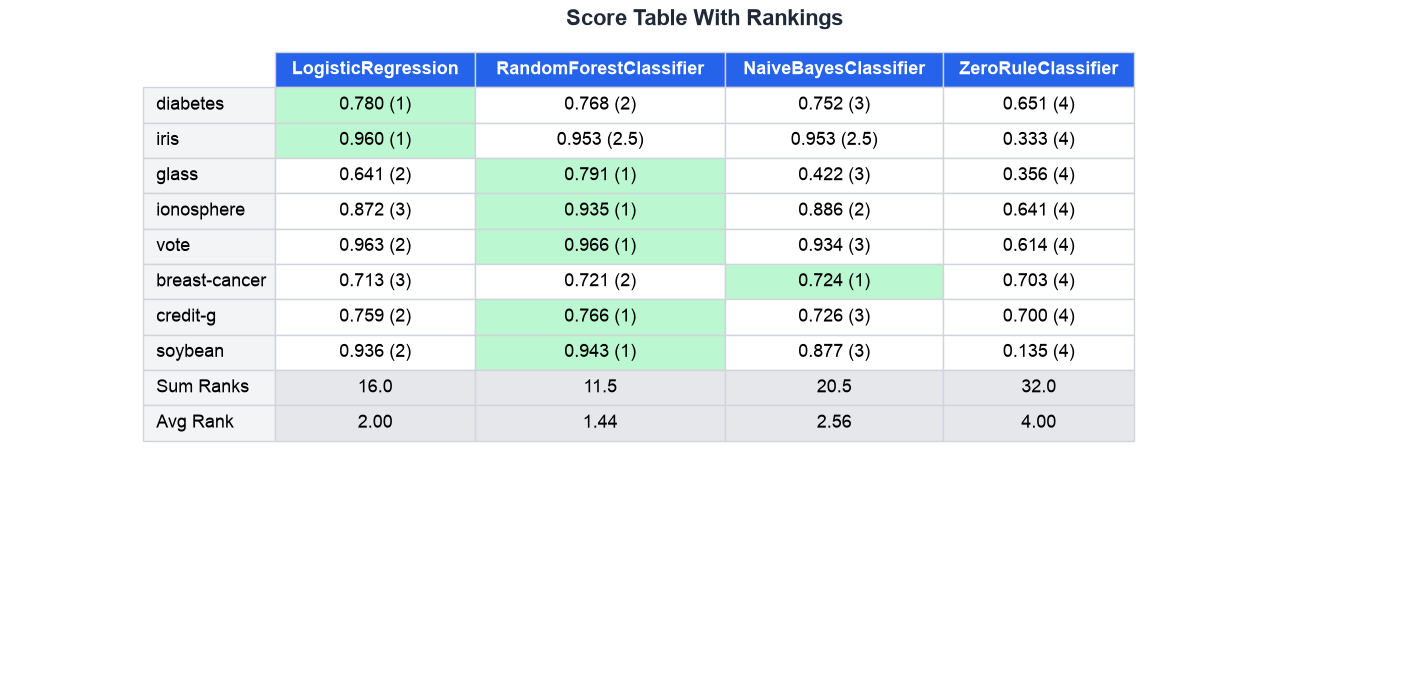

In [6]:
benchmark.plot_ranking()
plt.show()

The **Friedman test** then asks whether the spread of those average ranks is larger than chance would produce. If it is, a post-hoc **Nemenyi test** determines which specific pairs differ, and yields a *critical difference*: the distance two average ranks must be apart before the gap means anything.

That is what a CD diagram plots. Models sit on a rank axis, and a horizontal bar joins any group that is **not** statistically distinguishable.

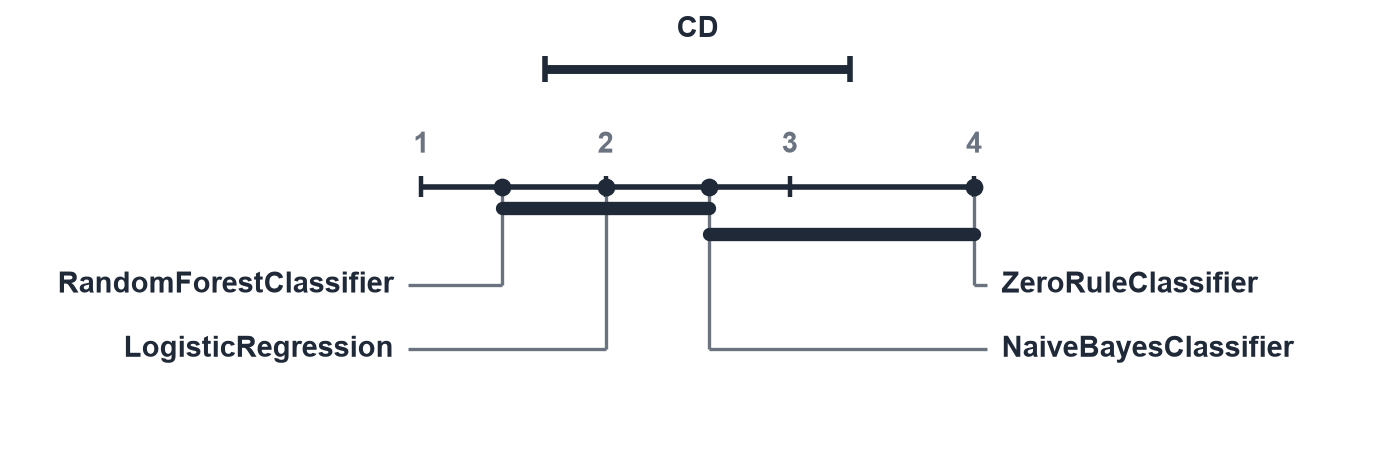

In [7]:
benchmark.plot_critical_difference()
plt.show()

Read it left to right: better ranks are on the left. Any two models connected by a bar are, on this evidence, tied. This one plot is the whole comparison — it is the standard figure in machine learning papers for exactly this reason, and it comes from Demšar's 2006 paper on comparing classifiers over multiple datasets.

The distribution of raw scores is worth a look too, since ranks deliberately discard magnitude:

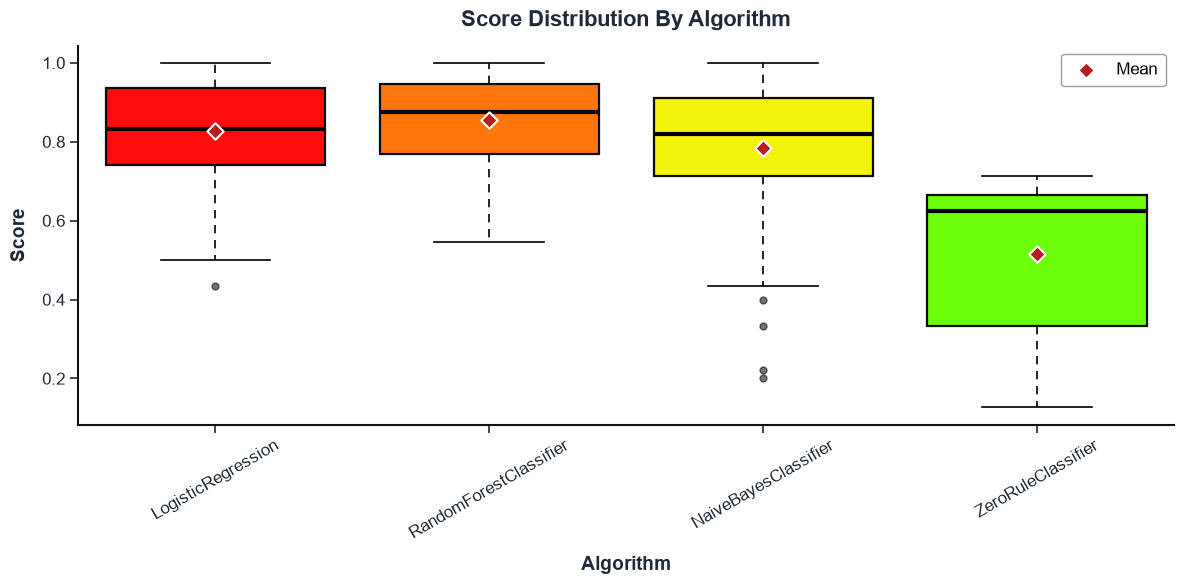

In [8]:
benchmark.plot_boxplot()
plt.show()

## 8.5 Reporting

`summary()` prints the per-dataset breakdown in full, and the table exports to whatever your write-up needs.

In [9]:
print(benchmark.to_markdown()[:1200])

| Dataset | LogisticRegression | RandomForestClassifier | NaiveBayesClassifier | ZeroRuleClassifier |
|---|---|---|---|---|
| diabetes | **0.7798 ± 0.0451** | 0.7682 ± 0.0494 | 0.7525 ± 0.0534 | 0.6511 ± 0.0036 |
| iris | **0.9600 ± 0.0562** | 0.9533 ± 0.0549 | 0.9533 ± 0.0549 | 0.3333 ± 0.0000 |
| glass | 0.6411 ± 0.1161 | **0.7915 ± 0.1277** | 0.4221 ± 0.1354 | 0.3557 ± 0.0151 |
| ionosphere | 0.8719 ± 0.0548 | **0.9348 ± 0.0420** | 0.8862 ± 0.0640 | 0.6411 ± 0.0060 |
| vote | 0.9633 ± 0.0245 | **0.9657 ± 0.0288** | 0.9336 ± 0.0506 | 0.6138 ± 0.0039 |
| breast-cancer | 0.7128 ± 0.0759 | 0.7206 ± 0.0856 | **0.7241 ± 0.0880** | 0.7030 ± 0.0123 |
| credit-g | 0.7590 ± 0.0288 | **0.7660 ± 0.0350** | 0.7260 ± 0.0327 | 0.7000 ± 0.0000 |
| soybean | 0.9357 ± 0.0257 | **0.9430 ± 0.0216** | 0.8768 ± 0.0225 | 0.1348 ± 0.0050 |


`to_latex()`, `to_html()` and `to_csv(path)` are also available. The LaTeX output is the one that saves an afternoon, since it emits a table you can paste into a paper directly.

## 8.6 What a defensible comparison needs

Pulling together the threads of the last seven chapters, a model comparison you could put your name to has:

1. **A baseline.** `ZeroRuleClassifier`, always. Two of our eight datasets barely beat it.
2. **Identical conditions.** Same folds, same preprocessing, same seed for every model. `Benchmark` enforces this.
3. **Preprocessing inside the fold.** Chapters 3 to 6. The `pipeline` argument does it for you.
4. **More than one dataset**, if you want to claim anything about algorithms rather than about your data.
5. **A significance test**, so "better" means something. Corrected, not naive.
6. **The spread, not just the mean.** Chapter 2.
7. **Tuning reported honestly.** Chapter 7 — nested CV, or a test set touched once.

Miss the first and you might be celebrating a model that loses to a constant. Miss the fifth and you are reporting noise.

## Recap

- `Benchmark(models, datasets, pipeline, evaluation)` runs the full cross-product on identical folds.
- **The winner is dataset-dependent.** The forest took five of eight datasets and the best overall rank; logistic regression won `diabetes`; naive Bayes won `breast-cancer`.
- Include `ZeroRuleClassifier`. On two datasets here the real models barely beat it.
- `compare(baseline)` runs a **corrected paired t-test** — paired because folds are shared, corrected because they overlap.
- Logistic regression's win over the forest on `diabetes` **is not statistically significant** — the gap is smaller than either model's fold-to-fold spread.
- "Not significant" means "cannot distinguish", not "identical".
- Average **ranks** across datasets, not scores; a CD diagram shows which models are indistinguishable.
- `to_markdown()`, `to_latex()`, `to_html()`, `to_csv()` for reporting.

**Next:** chapter 9 steps back from modelling and looks at the thing every chapter has quietly been building — the spec — and what it means that an experiment can be a piece of data.